In [12]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Ensure the notebook can read your backend directory structure
sys.path.append(os.path.abspath(os.path.join('..', 'backend')))

print("Environment path successfully configured.")

Environment path successfully configured.


In [13]:
# Load your raw bitext training data sheet to pull test strings
df = pd.read_csv("../data/raw/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv")

# Sample a random subset of 500 rows for validation testing to keep memory light
test_df = df.sample(n=500, random_state=42)
print(f"Loaded {len(test_df)} test samples for model validation.")

Loaded 500 test samples for model validation.


In [14]:
from app.ai.intent import predict_intent_bert

y_true = test_df['intent'].tolist()
y_pred = []

print("Running batch inference via DistilBERT Pipeline... (This may take a moment)")
for index, row in test_df.iterrows():
    prediction = predict_intent_bert(row['instruction'])
    y_pred.append(prediction['intent'])

print("Inference step complete!")

Running batch inference via DistilBERT Pipeline... (This may take a moment)
Inference step complete!


In [15]:
# Print out precision, recall, and F1 metrics
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred))

=== CLASSIFICATION REPORT ===
                          precision    recall  f1-score   support

            cancel_order       1.00      1.00      1.00        14
            change_order       1.00      1.00      1.00        15
 change_shipping_address       1.00      1.00      1.00        16
  check_cancellation_fee       1.00      1.00      1.00        20
           check_invoice       1.00      1.00      1.00        19
   check_payment_methods       1.00      1.00      1.00        22
     check_refund_policy       1.00      1.00      1.00        18
               complaint       1.00      1.00      1.00        20
contact_customer_service       1.00      1.00      1.00        20
     contact_human_agent       1.00      1.00      1.00        30
          create_account       1.00      1.00      1.00        24
          delete_account       1.00      1.00      1.00        14
        delivery_options       1.00      1.00      1.00        22
         delivery_period       1.00      1.00

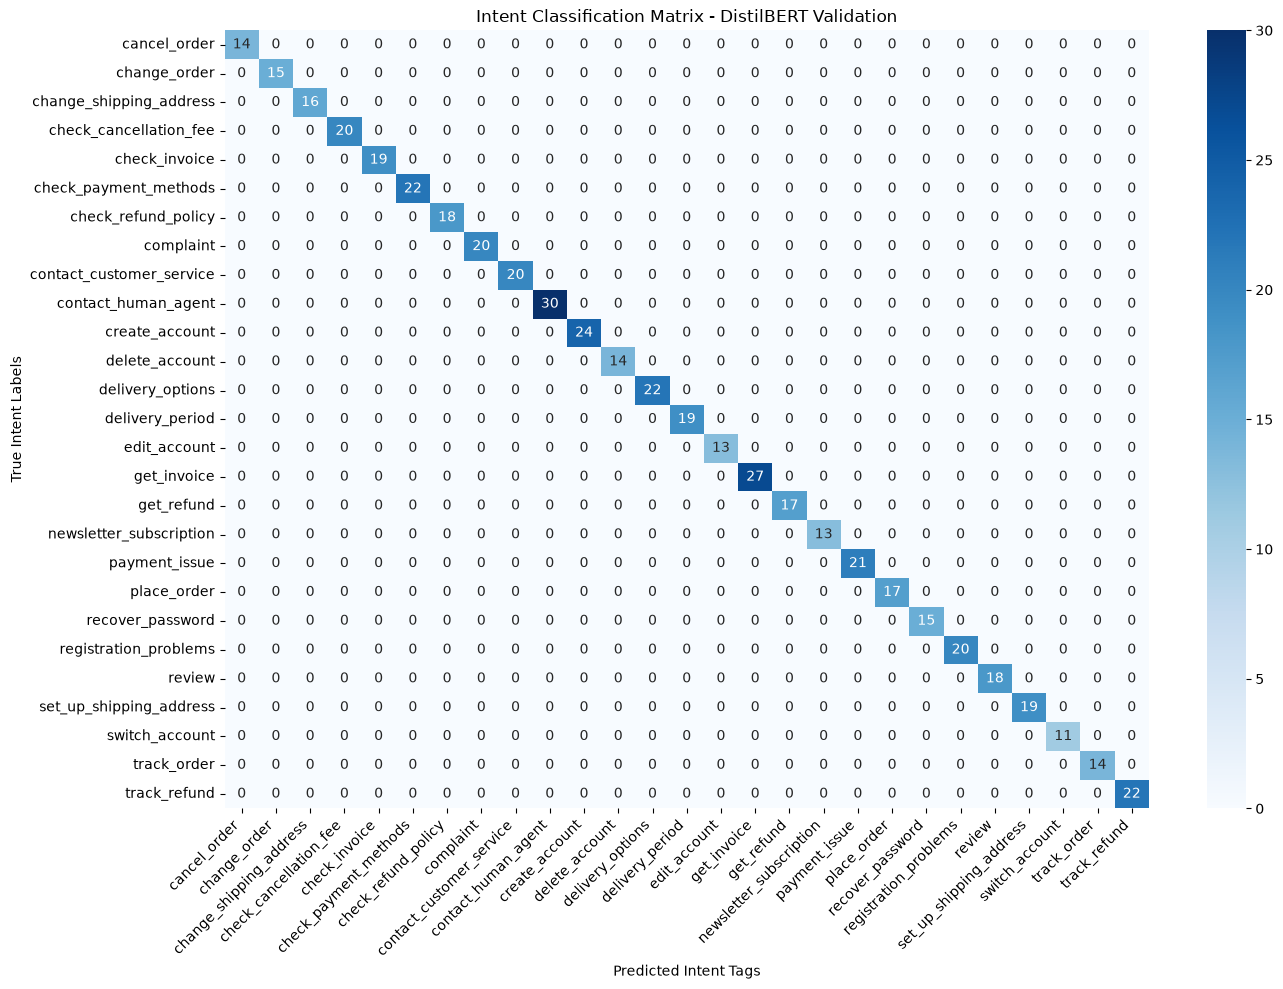

<Figure size 640x480 with 0 Axes>

In [16]:
# Generate matrix tracking predictions vs true labels
labels = sorted(list(set(y_true)))
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Intent Classification Matrix - DistilBERT Validation')
plt.xlabel('Predicted Intent Tags')
plt.ylabel('True Intent Labels')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# 3. Save the figure to your reports directory
plt.savefig(
    "../reports/figures/svm_confusion_matrix.png",
    dpi = 300,
    bbox_inches = "tight"
)
plt.show()